In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import pandas as pd
train_df = pd.read_csv("/content/drive/MyDrive/nlp_dataset/sent_train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/nlp_dataset/sent_valid.csv")

In [12]:
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (9543, 2)
Test Shape: (2388, 2)


In [13]:
train_df.head(20)

,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0
5,$FTI - TechnipFMC downgraded at Berenberg but ...,0
6,$GM - GM loses a bull https://t.co/tdUfG5HbXy,0
7,$GM: Deutsche Bank cuts to Hold https://t.co/7...,0
8,$GTT: Cowen cuts to Market Perform,0
9,$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...,0


In [14]:
test_df.head()

,text,label
0,$ALLY - Ally Financial pulls outlook https://t...,0
1,"$DELL $HPE - Dell, HPE targets trimmed on comp...",0
2,$PRTY - Moody's turns negative on Party City h...,0
3,$SAN: Deutsche Bank cuts to Hold,0
4,$SITC: Compass Point cuts to Sell,0


In [15]:
train_df.columns.equals(test_df.columns)

True

In [16]:
print(train_df.columns)
print(test_df.columns)

Index(['text', 'label'], dtype='object')
Index(['text', 'label'], dtype='object')


In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    9543 non-null   object
 1   label   9543 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 149.2+ KB


In [18]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2388 entries, 0 to 2387
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2388 non-null   object
 1   label   2388 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 37.4+ KB


In [19]:
train_df.isnull().sum()

,0
text,0
label,0


In [20]:
test_df.isnull().sum()

,0
text,0
label,0


In [21]:
train_df.duplicated().sum()

np.int64(0)

In [22]:
test_df.duplicated().sum()

np.int64(0)

In [23]:
print(train_df["label"].unique())
print(test_df["label"].unique())

[0 1 2]
[0 1 2]


In [24]:
for label in sorted(train_df["label"].unique()):
    print(f"\n===== Label {label} =====")
    print(
        train_df.loc[train_df["label"] == label, ["label", "text"]]
        .head(5)
        .to_string(index=False)
    )


===== Label 0 =====
 label                                                                                                   text
     0                          $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
     0 $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3
     0         $CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb
     0                                            $ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N
     0                                $FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB

===== Label 1 =====
 label                                                                   text
     1                               $ALTG: Dougherty & Company starts at Buy
     1 $AMD - AMD's Navi shows strong adoption - BofA https://t.co/WnCksfl1gX
     1                          $ANCUF: BMO Capital Markets ups 

$BYND - JPMorgan reels in expectations on Beyond Meat

In [25]:
label_map = {
    0: "Bearish",
    1: "Bullish",
    2: "Neutral"
}

train_df["sentiment"] = train_df["label"].map(label_map)
test_df["sentiment"] = test_df["label"].map(label_map)

#EDA

In [26]:
train_df["sentiment"].value_counts()

,count
sentiment,
Neutral,6178
Bullish,1923
Bearish,1442


In [27]:
train_df["label"].value_counts()

,count
label,
2,6178
1,1923
0,1442


In [28]:
train_df["label"].value_counts(normalize=True) * 100

,proportion
label,
2,64.738552
1,20.150896
0,15.110552


In [29]:
train_df.head()

,text,label,sentiment
0,$BYND - JPMorgan reels in expectations on Beyo...,0,Bearish
1,$CCL $RCL - Nomura points to bookings weakness...,0,Bearish
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0,Bearish
3,$ESS: BTIG Research cuts to Neutral https://t....,0,Bearish
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0,Bearish


##Bar Chart of Sentiment Distribution

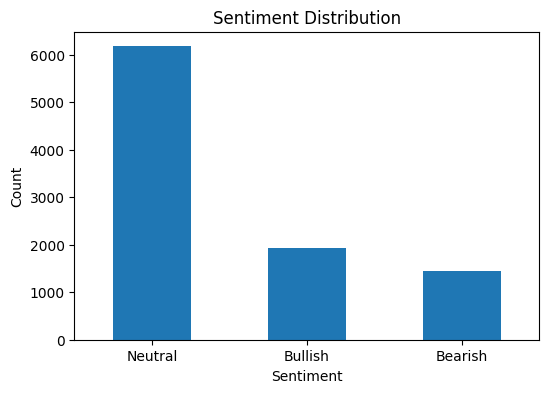

In [30]:
import matplotlib.pyplot as plt

train_df["sentiment"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

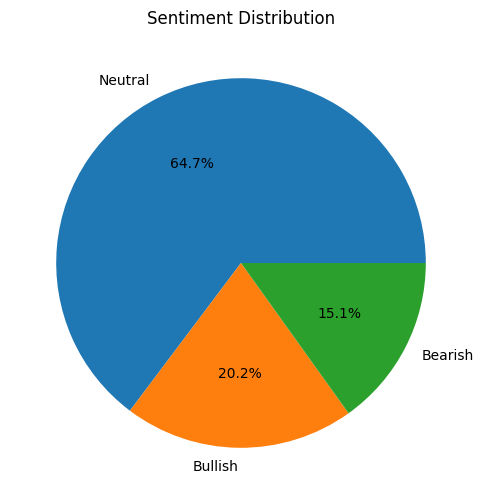

In [31]:
train_df["sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Sentiment Distribution")
plt.show()

Why Are We Measuring Tweet Length?

Later, when we tokenize the text, we'll need to choose a maximum sequence length (max_length).

Based on your data:

Most tweets are below 120 characters.
The maximum is 190 characters.

When using a tokenizer (especially for BERT), we'll likely choose a max_length around 128 tokens, which is sufficient for almost all tweets while keeping training efficient.

##Measuring Tweet Length

In [32]:
train_df["tweet_length"] = train_df["text"].apply(len)

In [33]:
train_df["tweet_length"].describe()

,tweet_length
count,9543.000000
mean,85.816934
std,35.097229
min,2.000000
25%,58.000000
50%,79.000000
75%,120.000000
max,190.000000


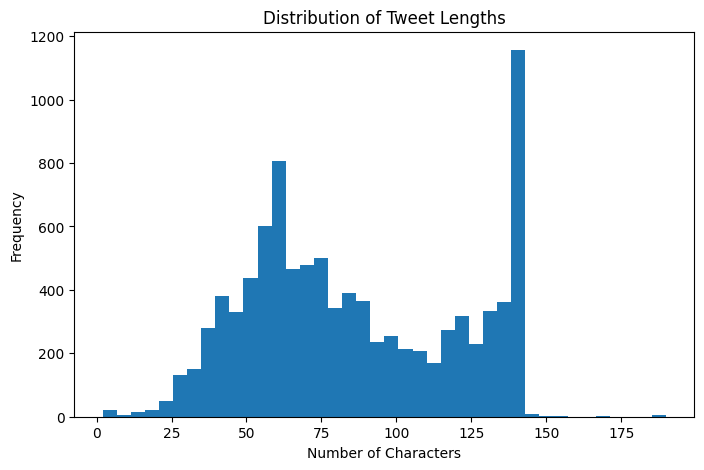

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(train_df["tweet_length"], bins=40)

plt.title("Distribution of Tweet Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

In [35]:
train_df.loc[train_df["tweet_length"].idxmax(), "text"]

'A Tokióban található teamLab Planets, a múzeum, ahol a víz a kiállítási közeg, idén tavasszal egy kis időre cseresznyevirág-szirmokba öltözik. A kiállítás 2020. március 1-től tekinthető meg.'

In [36]:
train_df.loc[train_df["tweet_length"].idxmin(), "text"]

':)'

#Text cleaning:preprocess

In [37]:
import re
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # Remove punctuation except $
    text = re.sub(r'[^\w\s$]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [38]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

In [39]:
comparison = pd.DataFrame({
    "Original": train_df["text"].head(10),
    "Cleaned": train_df["clean_text"].head(10)
})

comparison

,Original,Cleaned
0,$BYND - JPMorgan reels in expectations on Beyo...,$bynd jpmorgan reels in expectations on beyond...
1,$CCL $RCL - Nomura points to bookings weakness...,$ccl $rcl nomura points to bookings weakness a...
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",$cx cemex cut at credit suisse j p morgan on w...
3,$ESS: BTIG Research cuts to Neutral https://t....,$ess btig research cuts to neutral
4,$FNKO - Funko slides after Piper Jaffray PT cu...,$fnko funko slides after piper jaffray pt cut
5,$FTI - TechnipFMC downgraded at Berenberg but ...,$fti technipfmc downgraded at berenberg but ca...
6,$GM - GM loses a bull https://t.co/tdUfG5HbXy,$gm gm loses a bull
7,$GM: Deutsche Bank cuts to Hold https://t.co/7...,$gm deutsche bank cuts to hold
8,$GTT: Cowen cuts to Market Perform,$gtt cowen cuts to market perform
9,$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...,$hnhaf $hnhpd $aapl trendforce cuts iphone est...


In [40]:
train_df["clean_text"].head(10)

,clean_text
0,$bynd jpmorgan reels in expectations on beyond...
1,$ccl $rcl nomura points to bookings weakness a...
2,$cx cemex cut at credit suisse j p morgan on w...
3,$ess btig research cuts to neutral
4,$fnko funko slides after piper jaffray pt cut
5,$fti technipfmc downgraded at berenberg but ca...
6,$gm gm loses a bull
7,$gm deutsche bank cuts to hold
8,$gtt cowen cuts to market perform
9,$hnhaf $hnhpd $aapl trendforce cuts iphone est...


#Tokenization

In [41]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
VOCAB_SIZE = 10000
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

Important: Never fit the tokenizer on the test dataset. Doing so would leak information from the test set into the training process.

In [42]:
tokenizer.fit_on_texts(train_df["clean_text"])

In [43]:
train_sequences = tokenizer.texts_to_sequences(train_df["clean_text"])
test_sequences = tokenizer.texts_to_sequences(test_df["clean_text"])

In [44]:
print(train_df["clean_text"].iloc[0])

print(train_sequences[0])

$bynd jpmorgan reels in expectations on beyond meat
[5010, 790, 5011, 6, 398, 8, 907, 1150]


In [45]:
len(tokenizer.word_index)

15464

In [46]:
list(tokenizer.word_index.items())[:20]

[('<OOV>', 1),
 ('to', 2),
 ('the', 3),
 ('s', 4),
 ('of', 5),
 ('in', 6),
 ('a', 7),
 ('on', 8),
 ('for', 9),
 ('and', 10),
 ('stock', 11),
 ('is', 12),
 ('at', 13),
 ('as', 14),
 ('up', 15),
 ('with', 16),
 ('after', 17),
 ('marketscreener', 18),
 ('0', 19),
 ('by', 20)]

In [47]:
max_len = max(len(seq) for seq in train_sequences)

print("Maximum sequence length:", max_len)

Maximum sequence length: 32


In [48]:
import numpy as np

avg_len = np.mean([len(seq) for seq in train_sequences])

print("Average sequence length:", avg_len)

Average sequence length: 12.05480456879388


In [49]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LENGTH = 32

X_train = pad_sequences(
    train_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    test_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

In [50]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (9543, 32)
X_test shape: (2388, 32)


In [51]:
y_train = train_df["label"].values
y_test = test_df["label"].values

In [52]:
print(y_train.shape)
print(y_test.shape)

(9543,)
(2388,)


In [53]:
print("Original Tweet:")
print(train_df["clean_text"].iloc[0])

print("\nSequence:")
print(train_sequences[0])

print("\nPadded Sequence:")
print(X_train[0])

Original Tweet:
$bynd jpmorgan reels in expectations on beyond meat

Sequence:
[5010, 790, 5011, 6, 398, 8, 907, 1150]

Padded Sequence:
[5010  790 5011    6  398    8  907 1150    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0]


#Embedding + Simple RNN Model

In [54]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
X_train = torch.LongTensor(X_train)
X_test = torch.LongTensor(X_test)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [55]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

torch.Size([9543, 32])
torch.Size([9543])
torch.Size([2388, 32])
torch.Size([2388])


In [56]:
#create dataset
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

In [57]:
#create data loader
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [58]:
#Define Hyperparameters
VOCAB_SIZE = 10000

EMBEDDING_DIM = 128

HIDDEN_DIM = 128

OUTPUT_DIM = 3

NUM_LAYERS = 1

| Hyperparameter | Value | Reason                             |
| -------------- | ----: | ---------------------------------- |
| Vocabulary     | 10000 | Top frequent words                 |
| Embedding      |   128 | Standard embedding size            |
| Hidden Units   |   128 | Good balance of accuracy and speed |
| Output         |     3 | Bearish, Bullish, Neutral          |


#build the rnn model

In [59]:
import torch.nn as nn

#build the model
class SimpleRNN(nn.Module):

    def __init__(self):

        super(SimpleRNN, self).__init__()

        self.embedding = nn.Embedding(
            VOCAB_SIZE,
            EMBEDDING_DIM
        )

        self.rnn = nn.RNN(
            input_size=EMBEDDING_DIM,
            hidden_size=HIDDEN_DIM,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            HIDDEN_DIM,
            OUTPUT_DIM
        )

    def forward(self, x):

        embedded = self.embedding(x)

        output, hidden = self.rnn(embedded)

        hidden = self.dropout(hidden.squeeze(0))

        out = self.fc(hidden)

        return out

In [60]:
#Define Hyperparameters
VOCAB_SIZE = 10000
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
OUTPUT_DIM = 3

#Create the Model
model = SimpleRNN()

print(model)

SimpleRNN(
  (embedding): Embedding(10000, 128)
  (rnn): RNN(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [61]:
criterion = nn.CrossEntropyLoss()

In [62]:
import torch

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [63]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [64]:
for X_batch, y_batch in train_loader:
    print(X_batch.shape)
    print(y_batch.shape)
    break

torch.Size([32, 32])
torch.Size([32])


In [65]:
sample_batch, _ = next(iter(train_loader))

sample_batch = sample_batch.to(device)

output = model(sample_batch)

print(output.shape)

torch.Size([32, 3])


##training function

In [66]:
from sklearn.metrics import accuracy_score, f1_score
def train_model(model, dataloader, optimizer, criterion, device):

    model.train()

    running_loss = 0

    all_preds = []
    all_labels = []

    for X_batch, y_batch in dataloader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)

    accuracy = accuracy_score(all_labels, all_preds)

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    return epoch_loss, accuracy, macro_f1

##Evaluation function

In [67]:
def evaluate_model(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for X_batch, y_batch in dataloader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)

    accuracy = accuracy_score(all_labels, all_preds)

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    return epoch_loss, accuracy, macro_f1

In [68]:
EPOCHS = 10

In [69]:
train_losses = []
test_losses = []

train_accs = []
test_accs = []

train_f1s = []
test_f1s = []

In [70]:
for epoch in range(EPOCHS):

    train_loss, train_acc, train_f1 = train_model(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    test_loss, test_acc, test_f1 = evaluate_model(
        model,
        test_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    train_f1s.append(train_f1)
    test_f1s.append(test_f1)

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss : {train_loss:.4f} | Train Acc : {train_acc:.4f} | Train F1 : {train_f1:.4f}")

    print(f"Test Loss  : {test_loss:.4f} | Test Acc  : {test_acc:.4f} | Test F1  : {test_f1:.4f}")

    print("-"*60)

Epoch 1/10
Train Loss : 0.9115 | Train Acc : 0.6454 | Train F1 : 0.2636
Test Loss  : 0.8791 | Test Acc  : 0.6558 | Test F1  : 0.2640
------------------------------------------------------------
Epoch 2/10
Train Loss : 0.9004 | Train Acc : 0.6476 | Train F1 : 0.2628
Test Loss  : 0.8792 | Test Acc  : 0.6562 | Test F1  : 0.2655
------------------------------------------------------------
Epoch 3/10
Train Loss : 0.9006 | Train Acc : 0.6476 | Train F1 : 0.2628
Test Loss  : 0.8818 | Test Acc  : 0.6562 | Test F1  : 0.2655
------------------------------------------------------------
Epoch 4/10
Train Loss : 0.8963 | Train Acc : 0.6476 | Train F1 : 0.2628
Test Loss  : 0.8812 | Test Acc  : 0.6558 | Test F1  : 0.2640
------------------------------------------------------------
Epoch 5/10
Train Loss : 0.8968 | Train Acc : 0.6476 | Train F1 : 0.2628
Test Loss  : 0.8773 | Test Acc  : 0.6558 | Test F1  : 0.2640
------------------------------------------------------------
Epoch 6/10
Train Loss : 0.8967

In [71]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        actuals.extend(y_batch.numpy())

print(classification_report(actuals, predictions))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       347
           1       0.00      0.00      0.00       475
           2       0.66      1.00      0.79      1566

    accuracy                           0.66      2388
   macro avg       0.22      0.33      0.26      2388
weighted avg       0.43      0.66      0.52      2388



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [72]:
cm = confusion_matrix(actuals, predictions)

print(cm)

[[   0    0  347]
 [   0    0  475]
 [   0    0 1566]]


#define lstm model

In [73]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):

    def __init__(self):

        super(LSTMModel, self).__init__()

        self.embedding = nn.Embedding(
            VOCAB_SIZE,
            EMBEDDING_DIM
        )

        self.lstm = nn.LSTM(
            input_size=EMBEDDING_DIM,
            hidden_size=HIDDEN_DIM,
            num_layers=1,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            HIDDEN_DIM,
            OUTPUT_DIM
        )

    def forward(self, x):

        embedded = self.embedding(x)

        output, (hidden, cell) = self.lstm(embedded)

        hidden = self.dropout(hidden.squeeze(0))

        out = self.fc(hidden)

        return out

##Create the Model

In [74]:
lstm_model = LSTMModel().to(device)

print(lstm_model)

LSTMModel(
  (embedding): Embedding(10000, 128)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [75]:
#Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

In [76]:
train_losses = []
test_losses = []

train_accs = []
test_accs = []

train_f1s = []
test_f1s = []

##train lstm

In [77]:
EPOCHS = 10

for epoch in range(EPOCHS):

    train_loss, train_acc, train_f1 = train_model(
        lstm_model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    test_loss, test_acc, test_f1 = evaluate_model(
        lstm_model,
        test_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    train_f1s.append(train_f1)
    test_f1s.append(test_f1)

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss : {train_loss:.4f} | Train Acc : {train_acc:.4f} | Train F1 : {train_f1:.4f}")

    print(f"Test Loss  : {test_loss:.4f} | Test Acc  : {test_acc:.4f} | Test F1  : {test_f1:.4f}")

    print("-"*60)

Epoch 1/10
Train Loss : 0.8999 | Train Acc : 0.6456 | Train F1 : 0.2639
Test Loss  : 0.8786 | Test Acc  : 0.6558 | Test F1  : 0.2641
------------------------------------------------------------
Epoch 2/10
Train Loss : 0.8963 | Train Acc : 0.6476 | Train F1 : 0.2628
Test Loss  : 0.8774 | Test Acc  : 0.6562 | Test F1  : 0.2655
------------------------------------------------------------
Epoch 3/10
Train Loss : 0.8929 | Train Acc : 0.6476 | Train F1 : 0.2628
Test Loss  : 0.8787 | Test Acc  : 0.6562 | Test F1  : 0.2655
------------------------------------------------------------
Epoch 4/10
Train Loss : 0.8958 | Train Acc : 0.6476 | Train F1 : 0.2628
Test Loss  : 0.8787 | Test Acc  : 0.6562 | Test F1  : 0.2655
------------------------------------------------------------
Epoch 5/10
Train Loss : 0.8383 | Train Acc : 0.6581 | Train F1 : 0.3283
Test Loss  : 0.7389 | Test Acc  : 0.7182 | Test F1  : 0.4361
------------------------------------------------------------
Epoch 6/10
Train Loss : 0.6643

##evaluate lstm model

In [78]:
from sklearn.metrics import classification_report, confusion_matrix

lstm_model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = lstm_model(X_batch)

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        actuals.extend(y_batch.numpy())

print(classification_report(actuals, predictions))

              precision    recall  f1-score   support

           0       0.42      0.40      0.41       347
           1       0.64      0.52      0.57       475
           2       0.85      0.91      0.88      1566

    accuracy                           0.76      2388
   macro avg       0.64      0.61      0.62      2388
weighted avg       0.75      0.76      0.75      2388



In [79]:
cm = confusion_matrix(actuals, predictions)

print(cm)

[[ 140   91  116]
 [ 101  248  126]
 [  95   49 1422]]


#Define the GRU Mode

In [80]:
import torch
import torch.nn as nn

class GRUModel(nn.Module):

    def __init__(self):

        super(GRUModel, self).__init__()

        self.embedding = nn.Embedding(
            VOCAB_SIZE,
            EMBEDDING_DIM
        )

        self.gru = nn.GRU(
            input_size=EMBEDDING_DIM,
            hidden_size=HIDDEN_DIM,
            num_layers=1,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            HIDDEN_DIM,
            OUTPUT_DIM
        )

    def forward(self, x):

        embedded = self.embedding(x)

        output, hidden = self.gru(embedded)

        hidden = self.dropout(hidden.squeeze(0))

        out = self.fc(hidden)

        return out

##create the model

In [81]:
gru_model = GRUModel().to(device)

print(gru_model)

GRUModel(
  (embedding): Embedding(10000, 128)
  (gru): GRU(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


##Define Loss Function and Optimizer

In [82]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=0.001
)

In [83]:
#initialize Metric Lists
train_losses = []
test_losses = []

train_accs = []
test_accs = []

train_f1s = []
test_f1s = []

##train the model

In [84]:
EPOCHS = 10

for epoch in range(EPOCHS):

    train_loss, train_acc, train_f1 = train_model(
        gru_model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    test_loss, test_acc, test_f1 = evaluate_model(
        gru_model,
        test_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    train_f1s.append(train_f1)
    test_f1s.append(test_f1)

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss : {train_loss:.4f} | Train Acc : {train_acc:.4f} | Train F1 : {train_f1:.4f}")

    print(f"Test Loss  : {test_loss:.4f} | Test Acc  : {test_acc:.4f} | Test F1  : {test_f1:.4f}")

    print("-"*60)

Epoch 1/10
Train Loss : 0.8413 | Train Acc : 0.6631 | Train F1 : 0.3576
Test Loss  : 0.7092 | Test Acc  : 0.7060 | Test F1  : 0.4466
------------------------------------------------------------
Epoch 2/10
Train Loss : 0.6419 | Train Acc : 0.7317 | Train F1 : 0.5119
Test Loss  : 0.6300 | Test Acc  : 0.7379 | Test F1  : 0.5058
------------------------------------------------------------
Epoch 3/10
Train Loss : 0.4938 | Train Acc : 0.7993 | Train F1 : 0.6627
Test Loss  : 0.6072 | Test Acc  : 0.7588 | Test F1  : 0.6136
------------------------------------------------------------
Epoch 4/10
Train Loss : 0.3345 | Train Acc : 0.8750 | Train F1 : 0.8026
Test Loss  : 0.6142 | Test Acc  : 0.7822 | Test F1  : 0.6894
------------------------------------------------------------
Epoch 5/10
Train Loss : 0.2116 | Train Acc : 0.9273 | Train F1 : 0.8867
Test Loss  : 0.7318 | Test Acc  : 0.7785 | Test F1  : 0.6885
------------------------------------------------------------
Epoch 6/10
Train Loss : 0.1210

##Evaluate the Model

In [85]:
from sklearn.metrics import classification_report, confusion_matrix

gru_model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = gru_model(X_batch)

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        actuals.extend(y_batch.numpy())

print(classification_report(actuals, predictions))

              precision    recall  f1-score   support

           0       0.61      0.57      0.59       347
           1       0.74      0.60      0.66       475
           2       0.85      0.91      0.88      1566

    accuracy                           0.80      2388
   macro avg       0.73      0.69      0.71      2388
weighted avg       0.79      0.80      0.79      2388



In [86]:
cm = confusion_matrix(actuals, predictions)

print(cm)

[[ 197   28  122]
 [  54  284  137]
 [  71   73 1422]]
